In [1]:
import axelrod as axl
import matplotlib
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import numpy as np
import pandas as pd
import dask.dataframe as dd

import pathlib
import re

import sympy as sym

from itertools import combinations
import tqdm
from collections import defaultdict

from matplotlib.ticker import LinearLocator

### Helping Functions

In [2]:
def get_repetitions(filename):
    """
    Read the number of repetitions if included in the file name
    """
    match = re.search("[0-9]+(?=(_repetitions))", str(filename))
    return int(match.group(0))


def get_turns(filename):
    """
    Read the number of turns if included in the file name
    """
    match = re.search("[0-9]+(?=(_turns))", str(filename))
    return int(match.group(0))
    
def read_payoff_matrix(files):
    arrays = []
    turns = []
    repetitions = 0
    for gz_path in files:
        repetitions += get_repetitions(gz_path)
        arrays.append(np.array(pd.read_csv(str(gz_path), header=None)))  # Read through pd to deal with float conversion
        turns.append(get_turns(str(gz_path)))
    payoff_matrix = sum(array * turn for turn, array in zip(turns, arrays)) / sum(turns)
    
    return payoff_matrix, repetitions

def break_header(s):
    s = s.replace(" / ", r"\\")
    return r"\makecell[c]{" + s.replace("\n", r"\\") + "}"

### Data

In [3]:
full_tournament_data_path = pathlib.Path("./data/full_tournament/")

full_tournament_index = pd.read_csv(
    "./data/full_tournament/players.index",
    names=("Name",),
)
full_tournament_payoff_matrix = read_payoff_matrix(
                                   files=full_tournament_data_path.glob("*payoff_matrix.gz")
)

full_tournament_cooperation_rate_matrix = read_payoff_matrix(full_tournament_data_path.glob("*cooperation_rates.gz"))[0].transpose()

cooperation_rates = pd.DataFrame(full_tournament_cooperation_rate_matrix, 
                                 full_tournament_index["Name"], 
                                 columns=full_tournament_index["Name"])
cooperation_rates["Mean Cooperation Rate"] =  np.mean(full_tournament_cooperation_rate_matrix, axis=1)


### Extra invitations from the classical strategies

In [4]:
PayoffMatrix = full_tournament_payoff_matrix[0]

PayoffMatrix = pd.DataFrame(PayoffMatrix)
PayoffMatrix.index = full_tournament_index["Name"].values
PayoffMatrix.columns = full_tournament_index["Name"].values

In [5]:
CooperationfMatrix = full_tournament_cooperation_rate_matrix

CooperationfMatrix = pd.DataFrame(CooperationfMatrix)
CooperationfMatrix.index = full_tournament_index["Name"].values
CooperationfMatrix.columns = full_tournament_index["Name"].values

In [6]:
submitted = list(PayoffMatrix.index[:63])

classic_strategies = [
    "AON2",
    "Alternator",
    "Anti Tit For Tat",
    "Cooperator",
    "Defector",
    'EvolvedLookerUp2_2_2',
    "GTFT: 0.33",
    "Two Tits For Tat",
    "Win-Stay Lose-Shift",
]

### Table for introducing a single strategy or all

In [7]:
k92r_wins = 0
table = []

# Single-classic-strategy tournaments
for s1 in classic_strategies:
    players = submitted + [s1]

    scores = (
        PayoffMatrix.loc[players, players]
        .mean(axis=1)
        .sort_values(ascending=False)
    )

    rank_s1 = scores.index.get_loc(s1) + 1
    rank_k92r = scores.index.get_loc("k92r") + 1
    winner = scores.index[0]

    if winner == "k92r":
        k92r_wins += 1

    table.append({
        "Strategy": s1,
        "Rank": int(rank_s1),
        "k92r Rank": rank_k92r,
        "Winner": winner,
        "Winner / Average Score": scores.iloc[0],
        "Tournament / Average Score": scores.mean(),
    })


# Tournament with all classic strategies included
players = submitted + classic_strategies

scores = (
    PayoffMatrix.loc[players, players]
    .mean(axis=1)
    .sort_values(ascending=False)
)

winner = scores.index[0]

if winner == "k92r":
    k92r_wins += 1

table.append({
    "Strategy": "All Classical Strategies",
    "Rank": "-",
    "k92r Rank": scores.index.get_loc("k92r") + 1,
    "Winner": winner,
    "Winner / Average Score": scores.iloc[0],
    "Tournament / Average Score": scores.mean(),
})

table = pd.DataFrame(table)

In [8]:
table.columns = (
    table.columns
    .str.replace("_", " ", regex=False)
)

table = table.rename(columns={"Tournament": ""})

table = table.applymap(
    lambda x: x.replace("_", " ") if isinstance(x, str) else x
)

with open("../paper/assets/extra_invitations_classic_strategies.tex", "w") as f:
    f.write(table.rename(columns=break_header).to_latex(index=False, float_format="%.5f").replace("lrlrr", "cccccc").replace("\makecell[c]{Strategy}", "\makecell[l]{Strategy}"));

<>:13: SyntaxWarning: invalid escape sequence '\m'
<>:13: SyntaxWarning: invalid escape sequence '\m'
<>:13: SyntaxWarning: invalid escape sequence '\m'
<>:13: SyntaxWarning: invalid escape sequence '\m'
/var/folders/95/bfy4zf7n6p5248zz4wn2txfm0000gn/T/ipykernel_37934/3990884173.py:13: SyntaxWarning: invalid escape sequence '\m'
  f.write(table.rename(columns=break_header).to_latex(index=False, float_format="%.5f").replace("lrlrr", "cccccc").replace("\makecell[c]{Strategy}", "\makecell[l]{Strategy}"));
/var/folders/95/bfy4zf7n6p5248zz4wn2txfm0000gn/T/ipykernel_37934/3990884173.py:13: SyntaxWarning: invalid escape sequence '\m'
  f.write(table.rename(columns=break_header).to_latex(index=False, float_format="%.5f").replace("lrlrr", "cccccc").replace("\makecell[c]{Strategy}", "\makecell[l]{Strategy}"));
/var/folders/95/bfy4zf7n6p5248zz4wn2txfm0000gn/T/ipykernel_37934/3990884173.py:8: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  table = table.applymap

In [16]:
# let's look at TFT's scores when Anti TFT is there
players = submitted + ['Anti Tit For Tat']

scores = (
    PayoffMatrix.loc[players, players]
)
scores.loc['k92r'].sort_values(ascending=False), scores.loc['k42r'].sort_values(ascending=False)

(k31r                3.000000
 k56r                3.000000
 k58r                3.000000
 k88r                3.000000
 k60r                3.000000
                       ...   
 k77r                2.334531
 krandomc            2.245446
 Anti Tit For Tat    2.243709
 k36r                1.257807
 k71r                1.026490
 Name: k92r, Length: 64, dtype: float64,
 Anti Tit For Tat    3.533775
 k57r                3.000000
 k59r                3.000000
 k60r                3.000000
 k61r                3.000000
                       ...   
 k74r                2.161589
 k33r                2.137748
 k54r                1.990728
 k71r                1.347020
 k36r                1.199662
 Name: k42r, Length: 64, dtype: float64)

In [17]:
players = submitted + ['Defector']

scores = (
    PayoffMatrix.loc[players, players]
)
scores.loc['k92r'].sort_values(ascending=False), scores.loc['k42r'].sort_values(ascending=False)

(k31r        3.000000
 k56r        3.000000
 k58r        3.000000
 k88r        3.000000
 k60r        3.000000
               ...   
 k77r        2.334531
 krandomc    2.245446
 k36r        1.257807
 k71r        1.026490
 Defector    0.993377
 Name: k92r, Length: 64, dtype: float64,
 k31r        3.000000
 k55r        3.000000
 k57r        3.000000
 k58r        3.000000
 k88r        3.000000
               ...   
 k33r        2.137748
 k54r        1.990728
 k71r        1.347020
 k36r        1.199662
 Defector    0.953642
 Name: k42r, Length: 64, dtype: float64)

### Table of all combinations & Understanding the non monotonic behavior

In [9]:
rows = []

for k in range(1, len(classic_strategies)):
    for combo in combinations(classic_strategies, k):
        players = list(dict.fromkeys(submitted + list(combo)))

        scores = (
            PayoffMatrix.loc[players, players]
            .mean(axis=1)
            .sort_values(ascending=False)
        )

        cooperation = CooperationfMatrix.loc[players, players].mean().mean()

        winner = scores.index[0]

        rows.append({
            "k": k,
            "combo": combo,
            "winner": winner,
            "winner_payoff": scores.iloc[0],
            "tournament_avg_payoff": scores.mean(),
            "tournament_avg_cooperation": cooperation,
            "k92r_payoff": scores.loc["k92r"],
            "k92r_rank": scores.index.get_loc("k92r") + 1,
            "k42r_payoff": scores.loc["k42r"],
            "k42r_rank": scores.index.get_loc("k42r") + 1,
        })

tournament_results = pd.DataFrame(rows)

In [10]:
# tournament_results[(tournament_results["k"] == 2) & (tournament_results["k92r_rank"] == 2)]

In [11]:
# tournament_results[(tournament_results["k"] == 7) & (tournament_results["k92r_rank"] == 2)]

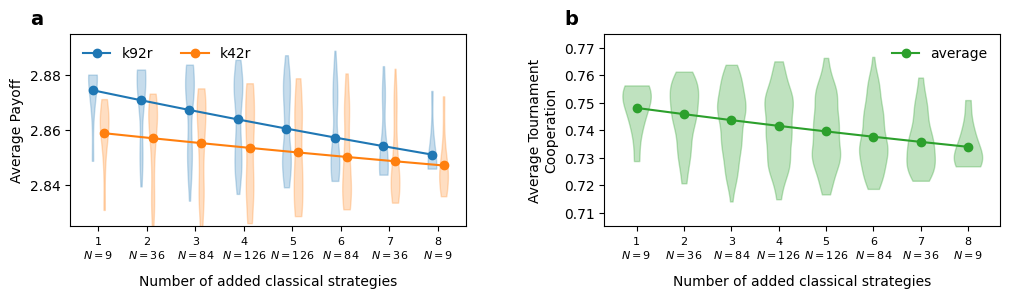

In [12]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 2.5),
    gridspec_kw={"wspace": 0.35}
)

ks = sorted(tournament_results["k"].unique())

n_by_subset = tournament_results.groupby("k").size()

xtick_labels = [
    f"{k}\n$N={n_by_subset[k]}$"
    for k in ks
]

strategies = {
    "k92r": {
        "column": "k92r_payoff",
        "offset": -0.12,
        "color": "tab:blue",
    },
    "k42r": {
        "column": "k42r_payoff",
        "offset": 0.12,
        "color": "tab:orange",
    },
}

ax = axes[0]

for strategy, params in strategies.items():

    grouped = [
        tournament_results.loc[
            tournament_results["k"] == k,
            params["column"]
        ].values
        for k in ks
    ]

    positions = [k + params["offset"] for k in ks]

    violin = ax.violinplot(
        grouped,
        positions=positions,
        widths=0.18,
        showmeans=True,
        showmedians=False,
        showextrema=False,
    )

    for body in violin["bodies"]:
        body.set_facecolor(params["color"])
        body.set_edgecolor(params["color"])
        body.set_alpha(0.25)

    ax.plot(
        positions,
        [values.mean() for values in grouped],
        marker="o",
        color=params["color"],
        label=strategy
    )

ax.set(
    xlabel="Number of added classical strategies",
    ylabel="Average Payoff",
    xticks=ks,
    xticklabels=xtick_labels,
    ylim=(2.825, 2.895)
)

ax.xaxis.labelpad = 10

ax.legend(frameon=False, ncols=2)

ax.text(
    -0.1,
    1.05,
    "a",
    transform=ax.transAxes,
    fontsize=14,
    fontweight="bold"
)

ax = axes[1]

grouped = [
    tournament_results.loc[
        tournament_results["k"] == k,
        "tournament_avg_cooperation"
    ].values
    for k in ks
]

violin = ax.violinplot(
    grouped,
    positions=ks,
    widths=0.6,
    showmeans=False,
    showmedians=False,
    showextrema=False,
)

for body in violin["bodies"]:
    body.set_facecolor("tab:green")
    body.set_edgecolor("tab:green")
    body.set_alpha(0.3)

ax.plot(
    ks,
    [values.mean() for values in grouped],
    marker="o",
    color="tab:green",
    label="average"
)

ax.set(
    xlabel="Number of added classical strategies",
    ylabel="Average Tournament\nCooperation",
    xticks=ks,
    xticklabels=xtick_labels,
    yticks=np.arange(0.71, 0.77, 0.01),
    ylim=(0.705, 0.775)
)

ax.xaxis.labelpad = 10

ax.legend(frameon=False)

ax.text(
    -0.1,
    1.05,
    "b",
    transform=ax.transAxes,
    fontsize=14,
    fontweight="bold"
)

for ax in axes:
    ax.tick_params(axis="x", labelsize=8)

fig.savefig(
    "../paper/assets/extra_invitations_classical_strategies.pdf",
    bbox_inches="tight"
)

In [13]:
win_counts = (
    tournament_results
    .groupby(["k", "winner"])
    .size()
    .unstack(fill_value=0)
)

win_percentages = win_counts.div(win_counts.sum(axis=1), axis=0)

table_percentages = win_percentages.T

subset_percentages = table_percentages.loc[["k92r", "k42r"]]

final_table = subset_percentages.copy()

# Remove column/index names (e.g. "winner")
final_table.columns.name = None
final_table.index.name = None

# Total tournaments for each k
totals = win_counts.sum(axis=1)

final_table.columns = [
    f"{k} New (N={totals[k]})"
    for k in final_table.columns
]

with open("../paper/assets/classical_strategies_combinations.tex", "w") as f:
    f.write(final_table.to_latex(float_format="%.5f"))

### Distributions of opponents

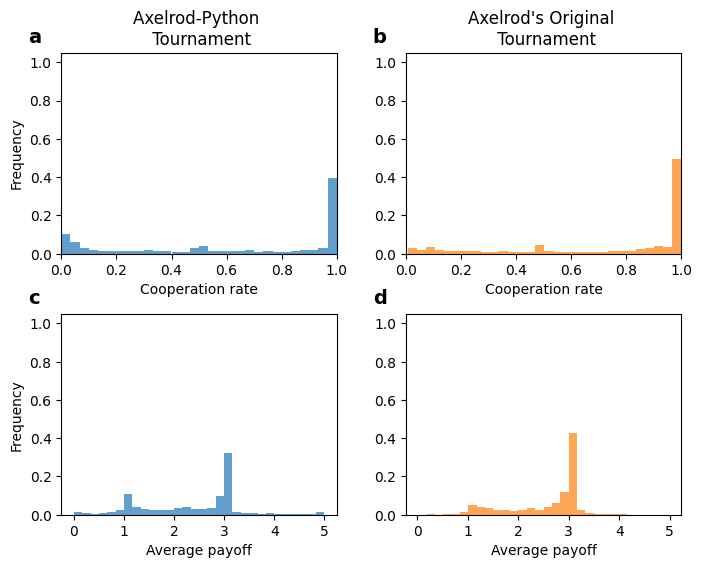

In [14]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(8, 6),
    # sharex="col",
    gridspec_kw={"wspace": 0.25, "hspace": 0.3}
)

cooperation_rates = pd.DataFrame(
    full_tournament_cooperation_rate_matrix,
    index=full_tournament_index["Name"],
    columns=full_tournament_index["Name"]
)

np.fill_diagonal(cooperation_rates.values, np.nan)

original_cooperation_rates = cooperation_rates.reindex(
    index=submitted,
    columns=submitted
)
payoffs = pd.DataFrame(
    full_tournament_payoff_matrix[0],
    index=full_tournament_index["Name"],
    columns=full_tournament_index["Name"]
)

np.fill_diagonal(payoffs.values, np.nan)

original_payoffs = payoffs.reindex(
    index=submitted,
    columns=submitted
)


full_coop_values = cooperation_rates.values.flatten()
full_coop_values = full_coop_values[
    ~np.isnan(full_coop_values)
]

original_coop_values = original_cooperation_rates.values.flatten()
original_coop_values = original_coop_values[
    ~np.isnan(original_coop_values)
]

full_payoff_values = payoffs.values.flatten()
full_payoff_values = full_payoff_values[
    ~np.isnan(full_payoff_values)
]

original_payoff_values = original_payoffs.values.flatten()
original_payoff_values = original_payoff_values[
    ~np.isnan(original_payoff_values)
]


def normalized_hist(ax, values, bins, color):

    weights = np.ones_like(values) / len(values)

    ax.hist(
        values,
        bins=bins,
        weights=weights,
        color=color,
        alpha=0.7
    )


expanded_color = "tab:blue"
original_color = "tab:orange"

# =========================================================
# Top row: cooperation distributions
# =========================================================

normalized_hist(
    axes[0, 0],
    full_coop_values,
    bins=30,
    color=expanded_color
)

axes[0, 0].set_title("Axelrod-Python \n Tournament")

normalized_hist(
    axes[0, 1],
    original_coop_values,
    bins=30,
    color=original_color
)

axes[0, 1].set_title("Axelrod's Original \n Tournament")

# =========================================================
# Bottom row: payoff distributions
# =========================================================

normalized_hist(
    axes[1, 0],
    full_payoff_values,
    bins=30,
    color=expanded_color
)

normalized_hist(
    axes[1, 1],
    original_payoff_values,
    bins=30,
    color=original_color
)

axes[0, 0].set_ylabel("Frequency")
axes[1, 0].set_ylabel("Frequency")

axes[0, 0].set_xlabel("Cooperation rate")
axes[0, 1].set_xlabel("Cooperation rate")

axes[1, 0].set_xlabel("Average payoff")
axes[1, 1].set_xlabel("Average payoff")

# cooperation axes
for ax in axes[0]:
    ax.set_xlim(0, 1)

# normalised y-axis
for ax in axes.flatten():
    ax.set_ylim(0, 1.05)

# panel labels
panel_labels = ["a", "b", "c", "d"]

for label, ax in zip(panel_labels, axes.flatten()):
    ax.text(
        -0.12,
        1.05,
        label,
        transform=ax.transAxes,
        fontsize=14,
        fontweight="bold"
    )

fig.savefig(
    "../paper/assets/distribution_of_opponents_comparison.pdf",
    bbox_inches="tight"
)

### Symmetry in Cooperation rates

In [21]:
players = submitted + classic_strategies

heatmap = cooperation_rates.reindex(
    index=players,
    columns=players
)

symmetric = heatmap - heatmap.T

k92r_symmetry = symmetric.loc["k92r"].drop("k92r")

k92r_symmetry_abs = k92r_symmetry.abs().sort_values(ascending=False)

k92r_symmetry_abs.head(10)

Name
k71r                0.006623
Defector            0.006623
k36r                0.006231
k74r                0.003974
krandomc            0.003296
k63r                0.002649
Anti Tit For Tat    0.002649
Alternator          0.002649
k89r                0.002649
k77r                0.001851
Name: k92r, dtype: float64

In [20]:
symmetric

array([[ 0.        ,  0.        , -0.10198675, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  0.        , -0.19968053, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.10198675,  0.19968053,  0.        , ..., -0.04711444,
         0.03311258, -0.46225166],
       ...,
       [ 0.        ,  0.        ,  0.04711444, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  0.        , -0.03311258, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.46225166, ...,  0.        ,
         0.        ,  0.        ]])